# 04 — Model Comparison + Per-Facility Shopping List (terminal deliverable)

This notebook does two things:

**A. Backtest comparison** of the three models (Statistical, LightGBM, XGBoost) on the 5-week test window. We compare them overall, by nest, by demand class, and by week. Output: `metrics.csv` and `evaluation_plots/*.png`.

**B. Production shopping list** — pick the champion ML model (lowest test WAPE), retrain it on **all** data (train + valid + test), score the upcoming week (`max_week + 7d`) for every (nest × facility × product) pair, and emit `facility_shopping_list_next_week.csv` — the actual deliverable: per facility, the products predicted to be needed, with units. Rare pairs use a transparent historical heuristic.

**Inputs:** `panel_weekly.parquet`, `unified_features.parquet`, `stat_predictions.csv`, `lgbm_predictions.csv`, `xgb_predictions.csv`.
**Outputs:** `metrics.csv`, `evaluation_plots/*.png`, `facility_shopping_list_next_week.csv`.


## Step 0 — Imports + load everything

In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110




In [ ]:
DATA_DIR = Path.cwd() / 'data'
PLOT_DIR = DATA_DIR / 'evaluation_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
PAIR_COLS = ['NEST_NAME', 'HEALTH_FACILITY_NAME', 'PRODUCT_NAME']
KEYS = PAIR_COLS + ['week_start']


In [ ]:
panel = pd.read_parquet(DATA_DIR / 'panel_weekly.parquet')
uni   = pd.read_parquet(DATA_DIR / 'unified_features.parquet')
stat  = pd.read_csv(DATA_DIR / 'stat_predictions.csv',  parse_dates=['week_start'])
lgbm  = pd.read_csv(DATA_DIR / 'lgbm_predictions.csv',  parse_dates=['week_start'])
xgbp  = pd.read_csv(DATA_DIR / 'xgb_predictions.csv',   parse_dates=['week_start'])
xgbh  = pd.read_csv(DATA_DIR / 'xgb_hard_predictions.csv', parse_dates=['week_start'])
print(f'stat rows={len(stat):,}  lgbm rows={len(lgbm):,}  '
      f'xgb_soft rows={len(xgbp):,}  xgb_hard rows={len(xgbh):,}')

UNDER_PENALTY = 3.0  # asymmetric loss weight (under-prediction penalised 3x)

stat rows=41,450  lgbm rows=41,450  xgb_soft rows=41,450  xgb_hard rows=41,450


## Step 1 — Outer-join the three prediction tables on (pair, week)

Every modellable pair × test week has 3 predictions. `demand_class` carried along for drill-downs.

In [ ]:
m = (stat.rename(columns={'y_pred': 'y_pred_stat'})[KEYS + ['y_actual', 'demand_class', 'y_pred_stat']]
         .merge(lgbm.rename(columns={'y_pred': 'y_pred_lgbm'})[KEYS + ['y_pred_lgbm']],
                on=KEYS, how='outer')
         .merge(xgbp.rename(columns={'y_pred': 'y_pred_xgb'})[KEYS + ['y_pred_xgb']],
                on=KEYS, how='outer')
         .merge(xgbh.rename(columns={'y_pred': 'y_pred_xgb_hard'})[KEYS + ['y_pred_xgb_hard']],
                on=KEYS, how='outer'))

# Where any model is missing, fill in actual y from the panel.
panel_test = panel[panel['split'] == 'test'][PAIR_COLS + ['week_start', 'weekly_units', 'demand_class']]
m = m.merge(panel_test.rename(columns={'weekly_units': 'y_actual_panel',
                                        'demand_class': 'demand_class_panel'}),
            on=KEYS, how='outer')
m['y_actual']     = m['y_actual'].fillna(m['y_actual_panel'])
m['demand_class'] = m['demand_class'].fillna(m['demand_class_panel'])
m = m.drop(columns=['y_actual_panel', 'demand_class_panel'])

for c in ['y_pred_stat', 'y_pred_lgbm', 'y_pred_xgb', 'y_pred_xgb_hard']:
    m[c] = m[c].fillna(0.0)

print(f'Merged rows: {len(m):,}   pairs: {m[PAIR_COLS].drop_duplicates().shape[0]:,}'
      f'   test weeks: {m["week_start"].nunique()}')
print('Per-nest row counts:')
print(m['NEST_NAME'].value_counts())


Merged rows: 241,780   pairs: 48,356   test weeks: 10
Per-nest row counts:
NEST_NAME
RW1 Muhanga    94650
RW2 Kayonza    57315
GH1 Omenako    46480
GH3 Vobsi      43335
Name: count, dtype: int64


## Step 2 — Metric helpers and overall + per-nest + per-class metrics

8 metrics: MAE, RMSE, Bias, WAPE, sMAPE, **Asym-WAPE** (3× under-penalty), **UPR** (under-prediction ratio), **OPR** (over-prediction ratio).

Four models compared: Statistical, LightGBM, **XGBoost soft** (P × mag), **XGBoost hard** (P ≥ per-class threshold → mag, else 0).

In [ ]:
def metrics_block(y, p):
    y = np.asarray(y, dtype=float); p = np.asarray(p, dtype=float)
    e = p - y
    denom = np.abs(y) + np.abs(p) + 1e-9
    # asymmetric: under-prediction (e < 0) penalised UNDER_PENALTY times more
    err_under = np.maximum(-e, 0)  # amount under-predicted per row
    err_over  = np.maximum( e, 0)  # amount over-predicted per row
    asym_loss = UNDER_PENALTY * err_under + err_over
    total_act = max(float(np.sum(np.abs(y))), 1e-9)
    return {
        'MAE':        float(np.mean(np.abs(e))),
        'RMSE':       float(np.sqrt(np.mean(e ** 2))),
        'Bias':       float(np.mean(e)),
        'WAPE':       float(np.sum(np.abs(e)) / total_act),
        'sMAPE_pct':  float(np.mean(200.0 * np.abs(e) / denom)),
        'AsymWAPE':   float(np.sum(asym_loss) / (UNDER_PENALTY * total_act)),
        'UPR':        float(np.sum(err_under) / total_act),
        'OPR':        float(np.sum(err_over)  / total_act),
    }

MODELS = {
    'Statistical':  'y_pred_stat',
    'LightGBM':     'y_pred_lgbm',
    'XGBoost_soft': 'y_pred_xgb',
    'XGBoost_hard': 'y_pred_xgb_hard',
}

def grouped_metrics(df, groupby_cols):
    rows = []
    if groupby_cols:
        for keys, g in df.groupby(groupby_cols, sort=False):
            base = dict(zip(groupby_cols, keys if isinstance(keys, tuple) else (keys,)))
            for mname, col in MODELS.items():
                rows.append({**base, 'model': mname, 'n_rows': len(g),
                             **metrics_block(g['y_actual'], g[col])})
    else:
        for mname, col in MODELS.items():
            rows.append({'model': mname, 'n_rows': len(df),
                         **metrics_block(df['y_actual'], df[col])})
    return pd.DataFrame(rows)

overall_metrics  = grouped_metrics(m, [])
nest_metrics     = grouped_metrics(m, ['NEST_NAME'])
class_metrics    = grouped_metrics(m, ['demand_class'])
week_metrics     = grouped_metrics(m, ['week_start'])

print('OVERALL:')
print(overall_metrics[['model','n_rows','MAE','RMSE','WAPE','AsymWAPE','UPR','OPR']].to_string(index=False))
print('\nBY NEST:')
print(nest_metrics[['NEST_NAME','model','MAE','WAPE','AsymWAPE','UPR','OPR']].to_string(index=False))
print('\nBY DEMAND CLASS:')
print(class_metrics[['demand_class','model','MAE','WAPE','AsymWAPE','UPR','OPR']].to_string(index=False))


OVERALL:
       model  n_rows      MAE      RMSE     WAPE  AsymWAPE      UPR      OPR
 Statistical  241780 1.471614 23.649214 1.337298  1.056067 0.915451 0.421847
    LightGBM  241780 1.555898 23.237615 1.413890  1.084245 0.919423 0.494467
XGBoost_soft  241780 1.940269 23.840165 1.763178  1.143776 0.834075 0.929103
XGBoost_hard  241780 1.192238 23.758835 1.083421  0.975658 0.921777 0.161644

BY NEST:
  NEST_NAME        model      MAE     WAPE  AsymWAPE      UPR      OPR
GH1 Omenako  Statistical 0.348359 1.162280  1.006471 0.928566 0.233714
GH1 Omenako     LightGBM 0.401145 1.338399  1.066237 0.930155 0.408244
GH1 Omenako XGBoost_soft 0.472428 1.576228  1.099196 0.860680 0.715548
GH1 Omenako XGBoost_hard 0.311713 1.040011  0.972115 0.938167 0.101844
  GH3 Vobsi  Statistical 0.730352 1.296857  1.030896 0.897916 0.398941
  GH3 Vobsi     LightGBM 0.761179 1.351596  1.034281 0.875623 0.475974
  GH3 Vobsi XGBoost_soft 0.952162 1.690717  1.050647 0.730612 0.960104
  GH3 Vobsi XGBoost_hard 0.6

## Step 3 — Save metrics tables

In [ ]:
all_metrics = pd.concat([
    overall_metrics.assign(slice='overall', slice_value='ALL'),
    nest_metrics.assign(slice='nest').rename(columns={'NEST_NAME': 'slice_value'}),
    class_metrics.assign(slice='demand_class').rename(columns={'demand_class': 'slice_value'}),
    week_metrics.assign(slice='week').rename(columns={'week_start': 'slice_value'}),
], ignore_index=True)

cols_first = ['slice', 'slice_value', 'model', 'n_rows',
              'MAE', 'RMSE', 'Bias', 'WAPE', 'sMAPE_pct', 'AsymWAPE', 'UPR', 'OPR']
all_metrics = all_metrics[cols_first]
all_metrics.to_csv(DATA_DIR / 'metrics.csv', index=False)
print(f'Saved metrics.csv  rows={len(all_metrics)}')


Saved metrics.csv  rows=80


## Step 4 — Plot 1: Overall MAE / WAPE / Asym-WAPE bars (4 models)

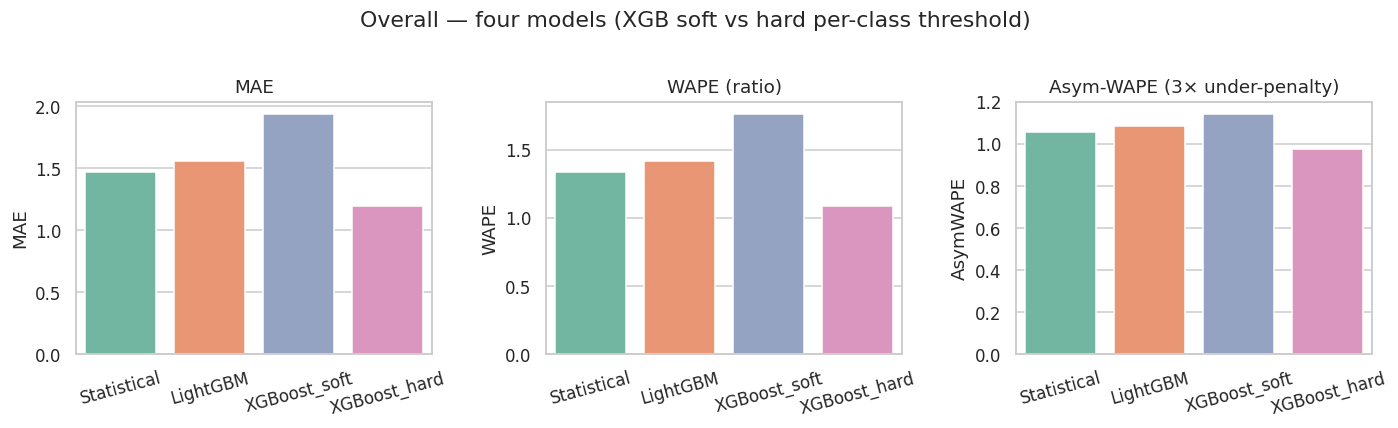

Saved 01_overall_metrics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, title in zip(axes,
                          ['MAE', 'WAPE', 'AsymWAPE'],
                          ['MAE', 'WAPE (ratio)', 'Asym-WAPE (3× under-penalty)']):
    sns.barplot(data=overall_metrics, x='model', y=col, ax=ax, palette='Set2')
    ax.set_title(title); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Overall — four models (XGB soft vs hard per-class threshold)', y=1.02)
plt.tight_layout()
p = PLOT_DIR / '01_overall_metrics.png'
plt.savefig(p, bbox_inches='tight'); plt.show()
print('Saved', p.name)


## Step 5 — Plot 2: per-nest MAE & WAPE (4 nests, side-by-side)

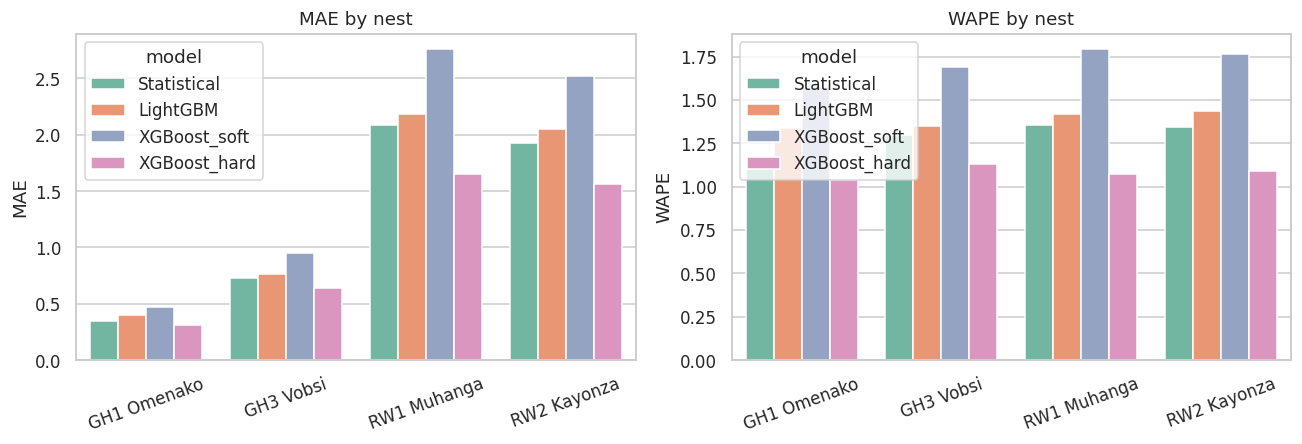

Saved 02_by_nest.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=nest_metrics, x='NEST_NAME', y='MAE',  hue='model', ax=axes[0], palette='Set2')
axes[0].set_title('MAE by nest');  axes[0].tick_params(axis='x', rotation=20); axes[0].set_xlabel('')
sns.barplot(data=nest_metrics, x='NEST_NAME', y='WAPE', hue='model', ax=axes[1], palette='Set2')
axes[1].set_title('WAPE by nest'); axes[1].tick_params(axis='x', rotation=20); axes[1].set_xlabel('')
plt.tight_layout()
p = PLOT_DIR / '02_by_nest.png'
plt.savefig(p, bbox_inches='tight'); plt.show()
print('Saved', p.name)


## Step 6 — Plot 3: per demand-class MAE & WAPE

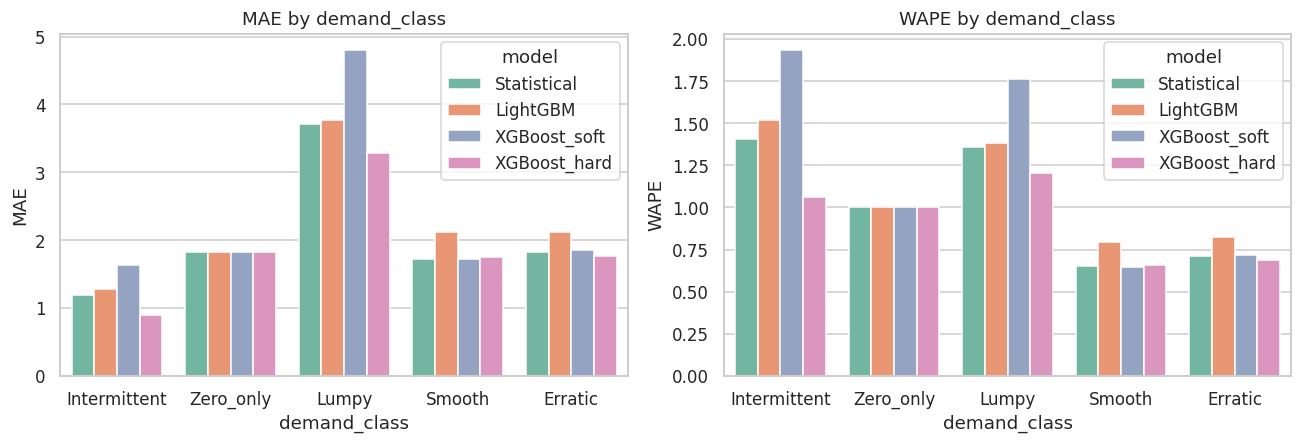

Saved 03_by_demand_class.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=class_metrics, x='demand_class', y='MAE',  hue='model', ax=axes[0], palette='Set2')
axes[0].set_title('MAE by demand_class')
sns.barplot(data=class_metrics, x='demand_class', y='WAPE', hue='model', ax=axes[1], palette='Set2')
axes[1].set_title('WAPE by demand_class')
plt.tight_layout()
p = PLOT_DIR / '03_by_demand_class.png'
plt.savefig(p, bbox_inches='tight'); plt.show()
print('Saved', p.name)


## Step 7 — Plot 4: MAE by test week (time drill-down)

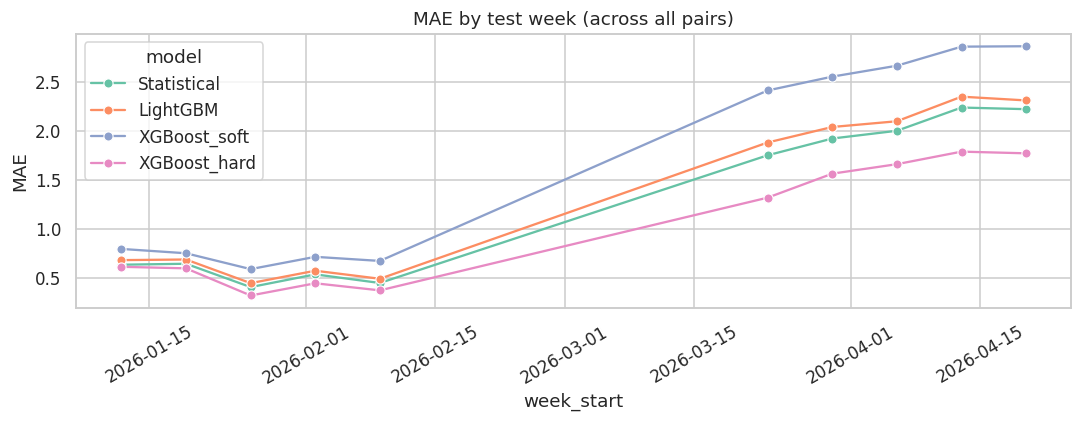

Saved 04_mae_by_week.png


In [ ]:
# Per-(nest, week) metrics so we can separate the two countries cleanly.
nestweek_metrics = grouped_metrics(m, ['NEST_NAME', 'week_start'])
nestweek_metrics['country'] = np.where(
    nestweek_metrics['NEST_NAME'].str.startswith('GH'), 'Ghana', 'Rwanda')

# Average across the nests within each country, per week, per model.
country_week = (nestweek_metrics
                .groupby(['country', 'week_start', 'model'], as_index=False)['MAE']
                .mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, country in zip(axes, ['Ghana', 'Rwanda']):
    sub = country_week[country_week['country'] == country].sort_values('week_start')
    sns.lineplot(data=sub, x='week_start', y='MAE', hue='model',
                 marker='o', ax=ax, palette='Set2')
    win = ('Jan-Feb 2026' if country == 'Ghana' else 'Mar-Apr 2026')
    ax.set_title(f'{country} test weeks ({win})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    if country == 'Ghana':
        ax.set_ylabel('MAE')
    # Keep one shared legend only.
    if ax.get_legend() is not None and country == 'Rwanda':
        ax.get_legend().remove()

axes[0].legend(title='model', fontsize=8)
plt.suptitle('MAE by test week — Ghana and Rwanda shown separately '
             '(different nests, different test windows)', y=1.04)
plt.tight_layout()
p = PLOT_DIR / '04_mae_by_week_split.png'
plt.savefig(p, bbox_inches='tight'); plt.show()
print('Saved', p.name)



## Step 8 — Pick the champion ML model by Asym-WAPE

Candidates: LightGBM, XGBoost_soft, XGBoost_hard. Lower Asym-WAPE wins — it penalises under-prediction 3× more than over-prediction.

In [ ]:
ml_overall = overall_metrics[overall_metrics['model'].isin(
    ['LightGBM', 'XGBoost_soft', 'XGBoost_hard'])]
champion = ml_overall.sort_values('AsymWAPE').iloc[0]['model']
print(f'Champion ML model (lower Asym-WAPE wins): {champion}')
print(ml_overall[['model', 'MAE', 'RMSE', 'WAPE', 'AsymWAPE', 'UPR', 'OPR']].to_string(index=False))


Champion ML model (lower Asym-WAPE wins): XGBoost_hard
       model      MAE      RMSE     WAPE  AsymWAPE      UPR      OPR
    LightGBM 1.555898 23.237615 1.413890  1.084245 0.919423 0.494467
XGBoost_soft 1.940269 23.840165 1.763178  1.143776 0.834075 0.929103
XGBoost_hard 1.192238 23.758835 1.083421  0.975658 0.921777 0.161644


## Step 9 — Production: rebuild the unified feature row for the upcoming week per nest

For each nest we add ONE new row per modellable pair at `week_start = nest_max_week + 7d`. We rebuild the lag / rolling / intermittent / history features using the **full** historical series (train + valid + test) so the upcoming-week features see all available info.

Note: the training above already used train-only features for honesty. Here we are doing inference, so we are allowed to feed the model whatever historical info is available at the moment of prediction.

In [ ]:
# Build a "production" panel that includes the modellable pair series only, with one extra week per nest.
mod_panel = panel[panel['tier'] == 'modellable'][PAIR_COLS + ['week_start', 'weekly_units']].copy()
mod_panel = mod_panel.sort_values(PAIR_COLS + ['week_start']).reset_index(drop=True)

# Determine next-week date per nest.
nest_next_week = (mod_panel.groupby('NEST_NAME')['week_start'].max()
                            .reset_index()
                            .assign(next_week=lambda d: d['week_start'] + pd.Timedelta(weeks=1))
                            [['NEST_NAME', 'next_week']])
print('Next prediction week per nest:')
print(nest_next_week.to_string(index=False))

# For each modellable pair, append a row for next_week with weekly_units=NaN (target unknown).
pair_to_nest = mod_panel[PAIR_COLS].drop_duplicates()
pair_to_nest = pair_to_nest.merge(nest_next_week, on='NEST_NAME', how='left')
extra_rows = pair_to_nest.rename(columns={'next_week': 'week_start'})
extra_rows['weekly_units'] = np.nan
prod_panel = pd.concat([mod_panel, extra_rows], ignore_index=True).sort_values(PAIR_COLS + ['week_start']).reset_index(drop=True)
print(f'Production panel rows: {len(prod_panel):,}  (mod_panel was {len(mod_panel):,})')


Next prediction week per nest:
  NEST_NAME  next_week
GH1 Omenako 2026-02-16
  GH3 Vobsi 2026-02-16
RW1 Muhanga 2026-04-27
RW2 Kayonza 2026-04-27
Production panel rows: 695,968  (mod_panel was 687,678)


## Step 10 — Recompute features on the production panel (same logic as Notebook 01)

Only the columns we actually need to feed the champion model.

In [ ]:
f = prod_panel.copy()

# Calendar
f['week_of_year'] = f['week_start'].dt.isocalendar().week.astype(int)
f['month']        = f['week_start'].dt.month
f['quarter']      = f['week_start'].dt.quarter
f['week_sin']     = np.sin(2 * np.pi * f['week_of_year'] / 52)
f['week_cos']     = np.cos(2 * np.pi * f['week_of_year'] / 52)
f['rainy_season'] = f['month'].between(4, 10).astype(int)

# Lags (treat NaN target as 0 for lag computation — units IS 0 except for the new row, where we don't shift it forward yet)
f['units_filled'] = f['weekly_units'].fillna(0.0)
g_units = f.groupby(PAIR_COLS, sort=False)['units_filled']
for k in [1, 2, 3, 4, 8, 12]:
    f[f'lag_{k}'] = g_units.shift(k)

# Rolling
shifted_units = f.groupby(PAIR_COLS, sort=False)['units_filled'].shift(1)
shifted_occ   = (shifted_units > 0).astype(float)
keys = [f[c] for c in PAIR_COLS]
for w in [4, 8, 13]:
    f[f'roll_mean_{w}']    = shifted_units.groupby(keys).transform(lambda s: s.rolling(w, min_periods=1).mean())
    f[f'roll_std_{w}']     = shifted_units.groupby(keys).transform(lambda s: s.rolling(w, min_periods=1).std().fillna(0))
    f[f'roll_max_{w}']     = shifted_units.groupby(keys).transform(lambda s: s.rolling(w, min_periods=1).max())
    f[f'roll_nz_rate_{w}'] = shifted_occ.groupby(keys).transform(lambda s: s.rolling(w, min_periods=1).mean())

# Intermittent (per-pair inline loop, past-only)
ws_all, lnz_all, hnz_all, ca_all = [], [], [], []
for _, g in f.groupby(PAIR_COLS, sort=False):
    units = g['units_filled'].to_numpy()
    n = len(units)
    ws  = np.full(n, np.nan); lnz = np.full(n, np.nan)
    hnz = np.full(n, np.nan); ca  = np.zeros(n)
    last_idx, last_val, cum = -1, np.nan, 0
    for i in range(n):
        if i > 0:
            hnz[i] = cum / i
            ca[i]  = cum
            if last_idx >= 0:
                ws[i] = i - last_idx; lnz[i] = last_val
        if units[i] > 0:
            last_idx, last_val, cum = i, units[i], cum + 1
    ws_all.extend(ws); lnz_all.extend(lnz); hnz_all.extend(hnz); ca_all.extend(ca)
f['weeks_since_last_demand'] = ws_all
f['last_nonzero_units']      = lnz_all
f['historical_nonzero_rate'] = hnz_all
f['cumulative_active_weeks'] = ca_all

# Expanding history (facility / product / pair) using filled units
fac = (f.groupby(['NEST_NAME', 'HEALTH_FACILITY_NAME', 'week_start'], as_index=False)['units_filled']
        .sum().rename(columns={'units_filled': 'fac_total'})
        .sort_values(['NEST_NAME', 'HEALTH_FACILITY_NAME', 'week_start']))
fac['fac_nz'] = (fac['fac_total'] > 0).astype(int)
gf = fac.groupby(['NEST_NAME', 'HEALTH_FACILITY_NAME'])
fac['facility_hist_mean']    = gf['fac_total'].transform(lambda s: s.shift(1).expanding().mean())
fac['facility_hist_nz_rate'] = gf['fac_nz'   ].transform(lambda s: s.shift(1).expanding().mean())
f = f.merge(fac[['NEST_NAME', 'HEALTH_FACILITY_NAME', 'week_start',
                 'facility_hist_mean', 'facility_hist_nz_rate']],
            on=['NEST_NAME', 'HEALTH_FACILITY_NAME', 'week_start'], how='left')

prod = (f.groupby(['NEST_NAME', 'PRODUCT_NAME', 'week_start'], as_index=False)['units_filled']
         .sum().rename(columns={'units_filled': 'prod_total'})
         .sort_values(['NEST_NAME', 'PRODUCT_NAME', 'week_start']))
prod['prod_nz'] = (prod['prod_total'] > 0).astype(int)
gp = prod.groupby(['NEST_NAME', 'PRODUCT_NAME'])
prod['product_hist_mean']    = gp['prod_total'].transform(lambda s: s.shift(1).expanding().mean())
prod['product_hist_nz_rate'] = gp['prod_nz'   ].transform(lambda s: s.shift(1).expanding().mean())
f = f.merge(prod[['NEST_NAME', 'PRODUCT_NAME', 'week_start',
                  'product_hist_mean', 'product_hist_nz_rate']],
            on=['NEST_NAME', 'PRODUCT_NAME', 'week_start'], how='left')

f = f.sort_values(PAIR_COLS + ['week_start']).reset_index(drop=True)
g_pair = f.groupby(PAIR_COLS, sort=False)['units_filled']
f['fp_hist_mean'] = g_pair.transform(lambda s: s.shift(1).expanding().mean())
f['fp_nz_tmp']    = (f['units_filled'] > 0).astype(int)
f['fp_hist_nz_rate'] = f.groupby(PAIR_COLS, sort=False)['fp_nz_tmp'].transform(lambda s: s.shift(1).expanding().mean())
f = f.drop(columns=['fp_nz_tmp', 'units_filled'])

# Pair-level numerics from the original panel (these are train-time stats; won't change for next week)
ps = uni[PAIR_COLS + ['adi', 'cv2', 'mean_nonzero', 'nonzero_weeks']].drop_duplicates(PAIR_COLS)
f = f.merge(ps, on=PAIR_COLS, how='left')

# Encodings (use the same LabelEncoder fit on the full unified set so encoding values match training)
fac_le = LabelEncoder().fit(uni['HEALTH_FACILITY_NAME'].astype(str))
prd_le = LabelEncoder().fit(uni['PRODUCT_NAME'].astype(str))
f['HEALTH_FACILITY_NAME_enc'] = fac_le.transform(f['HEALTH_FACILITY_NAME'].astype(str))
f['PRODUCT_NAME_enc']         = prd_le.transform(f['PRODUCT_NAME'].astype(str))

print('Production feature frame shape:', f.shape)
print('Rows for the upcoming next-week:')
print(f.merge(nest_next_week, left_on=['NEST_NAME', 'week_start'], right_on=['NEST_NAME', 'next_week'])
       .groupby('NEST_NAME').size())


Production feature frame shape: (695968, 45)
Rows for the upcoming next-week:
NEST_NAME
GH1 Omenako     848
GH3 Vobsi      1906
RW1 Muhanga    3554
RW2 Kayonza    1982
dtype: int64


## Step 11 — Retrain the champion model on full history and predict the next week

For LightGBM the champion is retrained as a single global model (unchanged). For XGBoost the champion is retrained using the **per-demand-class architecture** from Notebook 03: a separate `(clf, reg)` pair with class-specific features is fitted for each of the four demand classes (Smooth / Erratic / Intermittent / Lumpy). The next-week row for each (facility, product) pair is then scored by its own class model.

In [ ]:
# ── Shared feature list used by LightGBM (global) and as fallback ──────────────
FEATURES = [
    'week_of_year', 'month', 'quarter', 'week_sin', 'week_cos', 'rainy_season',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'lag_12',
    'roll_mean_4', 'roll_std_4', 'roll_max_4', 'roll_nz_rate_4',
    'roll_mean_8', 'roll_std_8', 'roll_max_8', 'roll_nz_rate_8',
    'roll_mean_13', 'roll_std_13', 'roll_max_13', 'roll_nz_rate_13',
    'weeks_since_last_demand', 'last_nonzero_units',
    'historical_nonzero_rate', 'cumulative_active_weeks',
    'facility_hist_mean', 'facility_hist_nz_rate',
    'product_hist_mean',  'product_hist_nz_rate',
    'fp_hist_mean',       'fp_hist_nz_rate',
    'adi', 'cv2', 'mean_nonzero', 'nonzero_weeks',
    'HEALTH_FACILITY_NAME_enc', 'PRODUCT_NAME_enc',
]

# ── Per-class feature subsets (mirror of Notebook 03) ───────────────────────────
XGB_FEATURE_SETS = {
    'Smooth': [
        'week_of_year', 'month', 'quarter', 'week_sin', 'week_cos', 'rainy_season',
        'lag_1', 'lag_2', 'lag_3', 'lag_4',
        'roll_mean_4', 'roll_std_4', 'roll_max_4', 'roll_nz_rate_4',
        'roll_mean_8', 'roll_std_8', 'roll_max_8', 'roll_nz_rate_8',
        'historical_nonzero_rate', 'cumulative_active_weeks',
        'facility_hist_mean', 'facility_hist_nz_rate',
        'product_hist_mean',  'product_hist_nz_rate',
        'fp_hist_mean',       'fp_hist_nz_rate',
        'adi', 'cv2', 'mean_nonzero', 'nonzero_weeks',
        'HEALTH_FACILITY_NAME_enc', 'PRODUCT_NAME_enc',
    ],
    'Erratic': [
        'week_of_year', 'month', 'quarter', 'week_sin', 'week_cos', 'rainy_season',
        'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'lag_12',
        'roll_mean_4',  'roll_std_4',  'roll_max_4',  'roll_nz_rate_4',
        'roll_mean_8',  'roll_std_8',  'roll_max_8',  'roll_nz_rate_8',
        'roll_mean_13', 'roll_std_13', 'roll_max_13', 'roll_nz_rate_13',
        'weeks_since_last_demand', 'last_nonzero_units',
        'historical_nonzero_rate', 'cumulative_active_weeks',
        'facility_hist_mean', 'facility_hist_nz_rate',
        'product_hist_mean',  'product_hist_nz_rate',
        'fp_hist_mean',       'fp_hist_nz_rate',
        'adi', 'cv2', 'mean_nonzero', 'nonzero_weeks',
        'HEALTH_FACILITY_NAME_enc', 'PRODUCT_NAME_enc',
    ],
    'Intermittent': [
        'week_of_year', 'month', 'quarter', 'week_sin', 'week_cos', 'rainy_season',
        'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12',
        'roll_nz_rate_4', 'roll_max_4',  'roll_mean_4',
        'roll_nz_rate_8', 'roll_max_8',  'roll_mean_8',
        'roll_nz_rate_13','roll_max_13', 'roll_mean_13',
        'weeks_since_last_demand', 'last_nonzero_units',
        'historical_nonzero_rate', 'cumulative_active_weeks',
        'facility_hist_mean', 'facility_hist_nz_rate',
        'product_hist_mean',  'product_hist_nz_rate',
        'fp_hist_mean',       'fp_hist_nz_rate',
        'adi', 'cv2', 'mean_nonzero', 'nonzero_weeks',
        'HEALTH_FACILITY_NAME_enc', 'PRODUCT_NAME_enc',
    ],
    'Lumpy': [
        'week_of_year', 'month', 'quarter', 'week_sin', 'week_cos', 'rainy_season',
        'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12',
        'roll_nz_rate_4', 'roll_max_4',  'roll_std_4',  'roll_mean_4',
        'roll_nz_rate_8', 'roll_max_8',  'roll_std_8',  'roll_mean_8',
        'roll_nz_rate_13','roll_max_13', 'roll_std_13', 'roll_mean_13',
        'weeks_since_last_demand', 'last_nonzero_units',
        'historical_nonzero_rate', 'cumulative_active_weeks',
        'facility_hist_mean', 'facility_hist_nz_rate',
        'product_hist_mean',  'product_hist_nz_rate',
        'fp_hist_mean',       'fp_hist_nz_rate',
        'adi', 'cv2', 'mean_nonzero', 'nonzero_weeks',
        'HEALTH_FACILITY_NAME_enc', 'PRODUCT_NAME_enc',
    ],
}
XGB_COMMON_PROD = dict(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1,
)
MIN_POS_FOR_STAGE2 = 30
DEMAND_CLASSES = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']

# ── Build full training frame (all splits, drop next-week rows) ──────────────────
full = f.merge(nest_next_week, on='NEST_NAME', how='left')
is_next = full['week_start'] == full['next_week']
full_train = full[~is_next].copy()
full_train['weekly_units'] = full_train['weekly_units'].fillna(0.0)
full_train = full_train.dropna(subset=['lag_1']).reset_index(drop=True)
next_rows  = full[is_next].copy()

# ── Attach demand_class to full_train and next_rows ──────────────────────────────
dc_map = uni[PAIR_COLS + ['demand_class']].drop_duplicates(PAIR_COLS)
full_train = full_train.merge(dc_map, on=PAIR_COLS, how='left')
full_train['demand_class'] = full_train['demand_class'].fillna('Intermittent')
next_rows  = next_rows.merge(dc_map, on=PAIR_COLS, how='left')
next_rows['demand_class']  = next_rows['demand_class'].fillna('Intermittent')

y_full   = full_train['weekly_units'].astype(float)
occ_full = (y_full > 0).astype(int)
pos_mask_global = (y_full > 0).to_numpy()
spw_global = float((occ_full == 0).sum()) / max(float((occ_full == 1).sum()), 1)
print(f'Full retrain rows: {len(full_train):,}  positive: {int(pos_mask_global.sum()):,}')

# ── LightGBM — global retrain (unchanged) ────────────────────────────────────────
# champion is one of: 'LightGBM', 'XGBoost_soft', 'XGBoost_hard'
# Both XGBoost variants use the same per-class architecture; only training convention differs
if champion == 'LightGBM':
    X_full = full_train[FEATURES].fillna(-999)
    clf = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                              min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=spw_global, random_state=42, verbosity=-1)
    clf.fit(X_full, occ_full)
    reg = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31,
                             min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=-1)
    reg.fit(X_full[pos_mask_global], np.log1p(y_full[pos_mask_global]))
    X_next = next_rows[FEATURES].fillna(-999)
    prob = clf.predict_proba(X_next)[:, 1]
    mag  = np.expm1(reg.predict(X_next)).clip(min=0)
    next_rows['predicted_units'] = np.clip(prob * mag, 0, None)
    next_rows['s1_prob'] = prob
    next_rows['s2_mag']  = mag
    print(f'LightGBM champion: scored {len(next_rows):,} next-week rows')
else:  # XGBoost_soft or XGBoost_hard — use per-class architecture

# ── XGBoost — per-demand-class retrain ───────────────────────────────────────────
    PROD_MODELS = {}
    for dc in DEMAND_CLASSES:
        feats_dc = XGB_FEATURE_SETS[dc]
        ft_dc = full_train[full_train['demand_class'] == dc].reset_index(drop=True)
        if len(ft_dc) == 0:
            print(f'  [{dc}] no rows, skipping'); continue

        X_dc  = ft_dc[feats_dc].fillna(-999)
        y_dc  = ft_dc['weekly_units'].astype(float)
        occ_dc = (y_dc > 0).astype(int)
        pos_dc = (y_dc > 0).to_numpy()
        n_pos  = int(pos_dc.sum())
        spw_dc = float((occ_dc == 0).sum()) / max(n_pos, 1)

        clf_dc = xgb.XGBClassifier(**XGB_COMMON_PROD,
                                    objective='binary:logistic',
                                    eval_metric=['logloss', 'aucpr'],
                                    scale_pos_weight=spw_dc, verbosity=0)
        clf_dc.fit(X_dc, occ_dc)

        reg_dc = None
        if n_pos >= MIN_POS_FOR_STAGE2:
            reg_dc = xgb.XGBRegressor(**XGB_COMMON_PROD,
                                       objective='reg:squarederror',
                                       eval_metric='rmse', verbosity=0)
            reg_dc.fit(X_dc[pos_dc], np.log1p(y_dc[pos_dc]))

        PROD_MODELS[dc] = (clf_dc, reg_dc, feats_dc)
        print(f'  [{dc}] trained on {len(ft_dc):,} rows  pos={n_pos:,}  '
              f'stage2={reg_dc is not None}')

    # Score next-week rows by class
    pred_pieces = []
    for dc, (clf_dc, reg_dc, feats_dc) in PROD_MODELS.items():
        nr_dc = next_rows[next_rows['demand_class'] == dc].copy()
        if len(nr_dc) == 0: continue
        X_nr  = nr_dc[feats_dc].fillna(-999)
        prob  = clf_dc.predict_proba(X_nr)[:, 1]
        if reg_dc is not None:
            mag = np.expm1(reg_dc.predict(X_nr)).clip(min=0)
        else:
            mag = np.zeros(len(nr_dc))
        nr_dc['predicted_units'] = np.clip(prob * mag, 0, None)
        nr_dc['s1_prob'] = prob
        nr_dc['s2_mag']  = mag
        pred_pieces.append(nr_dc)
    next_rows = pd.concat(pred_pieces).sort_index()
    print(f'XGBoost per-class: scored {len(next_rows):,} next-week rows')


Full retrain rows: 679,388  positive: 118,125
  [Smooth] trained on 6,460 rows  pos=5,581  stage2=True
  [Erratic] trained on 680 rows  pos=568  stage2=True
  [Intermittent] trained on 524,862 rows  pos=86,569  stage2=True
  [Lumpy] trained on 147,386 rows  pos=25,407  stage2=True
XGBoost per-class: scored 8,290 next-week rows


## Step 12 — Heuristic for `rare` pairs

For pairs that the ML model never trained on (`tier == 'rare'`), use the transparent baseline:

`predicted_units = historical_mean_nonzero × historical_nonzero_rate`

This is the long-run expected demand per week assuming order arrivals follow the historical pattern. Calculated from `panel_weekly.parquet`.

In [ ]:
rare_panel = panel[panel['tier'] == 'rare'].copy()
rare_stats = (rare_panel.groupby(PAIR_COLS, as_index=False)
                .agg(historical_mean_nonzero=('weekly_units', lambda x: float(x[x > 0].mean()) if (x > 0).any() else 0.0),
                     historical_nonzero_rate=('weekly_units', lambda x: float((x > 0).mean()))))
rare_stats['predicted_units'] = rare_stats['historical_mean_nonzero'] * rare_stats['historical_nonzero_rate']
rare_stats = rare_stats.merge(nest_next_week, on='NEST_NAME', how='left').rename(columns={'next_week': 'week_start'})
rare_stats['s1_prob'] = np.nan
rare_stats['s2_mag']  = np.nan
print(f'Heuristic predictions for {len(rare_stats):,} rare pairs')


Heuristic predictions for 40,066 rare pairs


## Step 13 — Combine ML + heuristic into the final shopping list

In [ ]:
# Modellable predictions (from ML)
ml_part = next_rows[PAIR_COLS + ['week_start', 'predicted_units', 's1_prob', 's2_mag']].copy()
ml_part['tier'] = 'modellable'
ml_part['method'] = champion

# Rare predictions (from heuristic)
rare_part = rare_stats[PAIR_COLS + ['week_start', 'predicted_units', 's1_prob', 's2_mag']].copy()
rare_part['tier'] = 'rare'
rare_part['method'] = 'historical_heuristic'

shopping = pd.concat([ml_part, rare_part], ignore_index=True)
# Attach demand_class for context.
dc_map = panel[PAIR_COLS + ['demand_class']].drop_duplicates(PAIR_COLS)
shopping = shopping.merge(dc_map, on=PAIR_COLS, how='left')
shopping['predicted_units_rounded'] = shopping['predicted_units'].round().astype(int).clip(lower=0)
shopping = shopping.rename(columns={'NEST_NAME': 'nest', 'HEALTH_FACILITY_NAME': 'facility',
                                      'PRODUCT_NAME': 'product'})

# Sort within each facility by predicted units descending.
shopping = shopping.sort_values(['nest', 'facility', 'predicted_units'], ascending=[True, True, False])
out_cols = ['nest', 'facility', 'product', 'week_start', 'predicted_units',
            'predicted_units_rounded', 'tier', 'demand_class', 'method', 's1_prob', 's2_mag']
shopping = shopping[out_cols].reset_index(drop=True)

shopping.to_csv(DATA_DIR / 'facility_shopping_list_next_week.csv', index=False)
print(f'Shopping list rows: {len(shopping):,}')
print(f'  modellable: {(shopping.tier=="modellable").sum():,}')
print(f'  rare:       {(shopping.tier=="rare").sum():,}')
print(f'  per-nest counts:')
print(shopping.groupby('nest').size())
print(f'\nSaved facility_shopping_list_next_week.csv')


Shopping list rows: 48,356
  modellable: 8,290
  rare:       40,066
  per-nest counts:
nest
GH1 Omenako     9296
GH3 Vobsi       8667
RW1 Muhanga    18930
RW2 Kayonza    11463
dtype: int64

Saved facility_shopping_list_next_week.csv


## Step 14 — Sample: top-10 predicted products for 3 random facilities

In [ ]:
sample_facilities = (shopping[['nest', 'facility']].drop_duplicates()
                                .sample(min(3, shopping[['nest','facility']].drop_duplicates().shape[0]), random_state=42))
for _, r in sample_facilities.iterrows():
    sub = (shopping[(shopping.nest == r['nest']) & (shopping.facility == r['facility'])]
              .head(10)[['product', 'predicted_units', 'predicted_units_rounded', 'tier', 'demand_class']])
    print(f'\n=== {r["nest"]}  |  {r["facility"]} (top 10 predicted products) ===')
    print(sub.to_string(index=False))



=== RW2 Kayonza  |  Bushara HC (top 10 predicted products) ===
                                        product  predicted_units  predicted_units_rounded       tier demand_class
       READY-TO-USE THERAPEUTIC FOODS (RUTF) 92        15.631766                       16 modellable Intermittent
         READY-TO-USE THERAPEUTIC FOODS(RUTF)92        10.869565                       11       rare Intermittent
        RIFT VALLEY FEVER VACCINE 100 DOSES B/1         4.380526                        4 modellable Intermittent
          SOLVENT RIFT VALLEY FEVER VACCINE B/1         4.335185                        4 modellable Intermittent
        LUMPY SKIN DISEASE VACCINE 50 DOSES B/1         3.403728                        3 modellable Intermittent
SOLVENT LUMPY SKIN DISEASE VACCINE 50 DOSES B/1         3.063248                        3 modellable Intermittent
                 URINE DIPSTCK 3 PARAMETER TEST         1.761684                        2 modellable Intermittent
                    A.I 